In [1]:
using Ferrite
using ModularEIT
using Images
using IterativeSolvers
using LinearAlgebra
using Plots
using Distributions
using Statistics
using Lux
using JLD2

In [2]:
η = 0.15

σf = 0.0e-2 # how much noise is added to f
σg = 0.0e-2 # How much noise is added to g
# Steers prox operators:
ρ_obj = 0.0

0.0

In [3]:
img = load("../reconstructions/1096.jpg")
img_f = img .|> Float64
img_f .-= 0.5
img_f .*= 2.0
img_f .= exp.(img_f) # Just an idea maybe EIT reconstruction is easier with this.

150×150 Matrix{Float64}:
 1.38471   1.39561   1.4066    1.4066    …  1.89499   1.88019   1.88019
 1.41768   1.42884   1.44009   1.44009      1.90992   1.90992   1.90992
 1.44009   1.45143   1.46286   1.46286      1.92495   1.92495   1.92495
 1.46286   1.47438   1.48599   1.48599      1.92495   1.92495   1.92495
 1.48599   1.49769   1.50948   1.50948      1.94011   1.94011   1.94011
 1.47438   1.48599   1.49769   1.49769   …  1.97078   1.97078   1.97078
 1.44009   1.45143   1.46286   1.46286      1.9863    1.9863    1.9863
 1.44009   1.45143   1.46286   1.46286      1.97078   1.9863    1.9863
 1.46286   1.46286   1.47438   1.48599      2.01771   2.00194   1.9863
 1.47438   1.48599   1.48599   1.49769      2.00194   2.00194   1.9863
 ⋮                                       ⋱                      
 0.367879  0.382593  0.388641  0.407368     0.388641  0.373696  0.388641
 0.394786  0.437162  0.385605  0.385605     0.394786  0.367879  0.373696
 0.385605  0.417066  0.42366   0.417066     0.39

In [4]:
itp = interpolate_array_2D(Float64.(img_f))

#interpolate_array_2D##0 (generic function with 1 method)

In [5]:
n = 63 
grid = generate_grid(Quadrilateral, (n, n));

In [6]:
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)
fe  = FerriteFESpace{RefQuadrilateral}(grid,2,0,3,∂Ω)

FerriteFESpace{RefQuadrilateral}(CellValues{Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}, Ferrite.GeometryMapping{1, Lagrange{RefQuadrilateral, 1}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Nothing}, QuadratureRule{RefQuadrilateral, Vector{Float64}, Vector{Vec{2, Float64}}}, Vector{Float64}}(Ferrite.FunctionValues{1, Lagrange{RefQuadrilateral, 2}, Matrix{Float64}, Matrix{Vec{2, Float64}}, Matrix{Vec{2, Float64}}, Nothing, Nothing}(Lagrange{RefQuadrilateral, 2}(), [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.007620999227554982; -0.05999999999999999 1.4605338811812958e-17 … -1.8551212633834227e-18 -0.059999999999999984; … ; 0.2749193338482966 -8.50014503228635e-18 … -8.500145032286352e-18 -0.03491933384829665; 0.15999999999999984 0.3999999999999998 … 0.3999999999999999 0.15999999999999992], [0.47237900077244527 -1.4605338811812958e-17 … 1.8551212633834227e-18 0.0076

In [7]:
cond_vec = project_function_to_fem(fe, itp; space=:σ)
cond_vec .= min.(max.(cond_vec, 1e-6), 2.8)

3969-element SparseArrays.SparseVector{Float64, Int64} with 3969 stored entries:
  [1   ]  =  1.43257
  [2   ]  =  1.4845
  [3   ]  =  1.46419
  [4   ]  =  1.47182
  [5   ]  =  1.49761
  [6   ]  =  1.5537
  [7   ]  =  1.59288
          ⋮
  [3962]  =  0.391354
  [3963]  =  0.405863
  [3964]  =  0.443788
  [3965]  =  0.403251
  [3966]  =  0.383249
  [3967]  =  0.386418
  [3968]  =  0.377171
  [3969]  =  0.382861

In [8]:
eval_points = reshape(equidistant_grid(64), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 4096
  Found corresponding cell for all points.

In [9]:
G_full = real_fourier_basis(8)
rhs_dict = Dict()
Threads.@threads for i in 2:256
    M = make_boundary(G_full[:, i],64)
    itp = interpolate_array_2D(M)
    rhs_dict[i-1] = assemble_rhs_func(fe, itp)
end
G = zeros(fe.n,255)
for i in 1:255
    G[:,i] = rhs_dict[i]
end

In [10]:
fbm_true =  FerriteBlockMode(cond_vec, G, fe; block=false)

FerriteBlockMode(ModularEIT.BlockLAssembler(9, [0.23822472205239942 -0.012762038681378523 … -0.07657223208827142 -0.13612841260137062; -0.012762038681378523 0.23822472205240014 … 0.042540128937928745 -0.1361284126013715; … ; -0.07657223208827142 0.042540128937928745 … 0.7487062693075427 -0.40838523780411423; -0.13612841260137062 -0.1361284126013715 … -0.40838523780411423 2.178054601621942]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0  …  1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0], sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 1  …  16129, 15868, 15872, 15874, 16122, 16123, 16126, 16127, 16128, 16129], [1, 1, 1, 1, 1, 1, 1, 1, 1, 2  …  16128, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129], [0.8913780897139235, -0.04775239766324571, -0.031834931775497274, -0.04775239766324583, -0.28651438597947626, 0.15917465887748627, 0.15917465887748627, -0.286514385979475, -0.5093589084079558, -0.04775239766324571  …  -0.4083852378041141, -0.13612841260137062, -0.1361284126013715, -

In [11]:
F = fbm_true.F
GS = copy(fe.down(fbm_true.G))
F, G , Σ = svd_on_modes(F,GS)

([-1.832369140527523 -4.637575440855417 … 3.1248765718670256e-7 -1.1862714609261156e-7; -1.8150962153055947 -4.577320945244406 … 4.061109388512828e-7 -1.4939256337280074e-7; … ; 16.792705029816005 7.848126890622102 … -1.5668779301634873e-6 5.861086256518276e-7; 16.79210051571045 7.844233978500449 … -1.570885195315517e-6 5.875149807783615e-7], [-0.008546200062766575 -0.02781195678906559 … 5.071591352630678e-7 -1.9240335885754974e-7; -0.008436492591953282 -0.02733666862811135 … 9.53812865135871e-7 -3.530143751941722e-7; … ; 0.15666707394011398 0.09415629064677057 … -8.272209127787946e-7 3.105128654271893e-7; 0.1566715134089007 0.09410411668735301 … -8.309663714239053e-7 3.118026725699007e-7], [135.92284289440354, 105.77919982238197, 59.81509715768693, 42.71272621801025, 37.908844852712356, 31.131690526215806, 28.618667862188175, 27.40050910560003, 21.45300431034049, 18.5383082430501  …  0.3377137518551025, 0.3341544895775894, 0.32787306744487527, 0.3197982904077519, 0.3028420139108179, 0

In [12]:
fbm = FerriteBlockMode(F, fe.up(G), fe)

FerriteBlockMode(ModularEIT.BlockLAssembler(9, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0  …  1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0], sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 1  …  16129, 15868, 15872, 15874, 16122, 16123, 16126, 16127, 16128, 16129], [1, 1, 1, 1, 1, 1, 1, 1, 1, 2  …  16128, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 16129, 16129), sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 16130  …  16112, 16114, 16116, 16118, 16120, 16122, 16124, 16126, 16127, 16128], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  16130, 16130, 16130, 16130, 16130, 16130, 16130, 16130, 16130, 16130], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0  …  1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 16130, 16130), [-1.832369140527523 -4.637575440855417 … 3.1248765718670256e-7 -1.1862714609261156e-7; 

In [13]:
f, ∂f =  create_block_f∂f(fbm, fe;
                           nmodes=100, block=true,
                           gn=true)

(ModularEIT.var"#53#54"{Int64, Bool, Float64, Nothing, Float64, FerriteBlockMode, FerriteFESpace{RefQuadrilateral}, Base.RefValue{Bool}, Base.RefValue{Float64}, Base.RefValue{Union{Nothing, Vector{Float64}}}}(100, true, 1.0, nothing, 0.0, FerriteBlockMode(ModularEIT.BlockLAssembler(9, [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]), [1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0  …  1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0], sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 1  …  16129, 15868, 15872, 15874, 16122, 16123, 16126, 16127, 16128, 16129], [1, 1, 1, 1, 1, 1, 1, 1, 1, 2  …  16128, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129, 16129], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 16129, 16129), sparse([1, 2, 3, 4, 5, 6, 7, 8, 9, 16130  …  16112, 16114, 16116, 16118, 16120, 16122, 16124, 16126, 16127, 16128], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  16130, 16130, 16130, 16130, 16130, 1613

In [17]:
prox_obj = create_proximal_gradient_step(f,∂f,ρ_obj, fe.n)

#94 (generic function with 1 method)

In [20]:
σ₁ = exp.(randn(64,64))


64×64 Matrix{Float64}:
 1.7777    0.368625  3.37608   2.43335   …  2.21681   0.601369  0.478578
 8.08243   2.28578   1.00872   0.276117     1.79586   0.207587  1.28493
 3.21182   0.314222  1.97875   0.647548     0.602906  0.911586  1.27174
 2.41795   1.12838   0.809663  0.730683     4.46487   1.53348   1.39567
 0.888085  0.49869   1.22222   1.30031      2.3778    0.718771  0.406946
 0.59988   0.861346  2.47213   0.274108  …  1.23056   0.622387  2.46134
 1.76358   0.42323   0.994903  1.24369      2.42811   1.85623   2.61462
 0.362587  0.617768  0.659044  5.1781       0.587871  2.77257   1.45981
 0.760867  3.14262   0.948162  1.26945      6.78419   0.836779  0.761026
 0.60826   1.25684   0.170006  3.3053       2.35248   0.472944  2.62266
 ⋮                                       ⋱                      
 0.824106  1.77275   4.08799   1.59981   …  1.50826   2.46454   2.92128
 7.18166   0.606891  3.62641   0.82295      0.593176  0.556668  0.499578
 0.772806  1.22983   1.19072   1.82737      

In [21]:
σᵢ, err, _ = prox_obj(σ₁) 

MethodError: MethodError: no method matching (::LBFGSB.L_BFGS_B)(::ModularEIT.var"#100#101"{Matrix{Float64}, ModularEIT.var"#53#54"{Int64, Bool, Float64, Nothing, Float64, FerriteBlockMode, FerriteFESpace{RefQuadrilateral}, Base.RefValue{Bool}, Base.RefValue{Float64}, Base.RefValue{Union{Nothing, Vector{Float64}}}}, Float64}, ::ModularEIT.var"#104#105", ::Matrix{Float64}, ::Matrix{Float64}; m::Int64, factr::Float64, pgtol::Float64, iprint::Int64, maxfun::Int64, maxiter::Int64)
The object of type `LBFGSB.L_BFGS_B` exists, but no method is defined for this combination of argument types when trying to treat it as a callable object.

Closest candidates are:
  (::LBFGSB.L_BFGS_B)(::Any, ::Any, !Matched::AbstractVector, ::AbstractMatrix; m, factr, pgtol, iprint, maxfun, maxiter)
   @ LBFGSB ~/.julia/packages/LBFGSB/UZibA/src/wrapper.jl:31
  (::LBFGSB.L_BFGS_B)(::Any, !Matched::AbstractVector, ::AbstractMatrix; m, factr, pgtol, iprint, maxfun, maxiter)
   @ LBFGSB ~/.julia/packages/LBFGSB/UZi

In [18]:
# Choose some starting sigma:

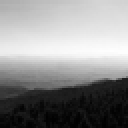

In [19]:
# cond_vec lives on the σ-space (fe.dh_σ), not the u-space (fe.dh) — must
# evaluate against fe.dh_σ to read the conductivity image back out.
cond_img = reshape(evaluate_at_points(ph, fe.dh_σ, cond_vec), (64, 64))
cond_img = Gray.(log.(cond_img) .*0.5 .+0.5)